<a href="https://colab.research.google.com/github/Dattatray685/python_notes_by_datta/blob/main/Data_Visualisation_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Topic: Data Visualization + Data Cleaning + NumPy Operations**



import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

# Load inbuilt dataset

df = sns.load_dataset("titanic")

df.head()

Q1. Display first 10 rows and dataset info.


Task:

Show first 10 rows

Print dataset shape

Show missing values

Intuition:

 observe:

Missing values in age, deck, embark_town

Mixture of categorical and numerical columns

Around 891 rows

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Q2.Find survival rate percentage.

Intuition:
Value will be around 38%.

This tells survival was difficult — class & gender might influence survival

In [ ]:
survival_rate = df['survived'].mean()*100
survival_rate

np.float64(38.38383838383838)

Q3. Fill missing Age values with mean.


Intuition:
Age is important numerical feature. Replacing with mean keeps distribution stable.

In [ ]:
df['age'].fillna(df['age'].mean(), inplace= True)
df['age']

/tmp/ipykernel_17757/1226866228.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace= True)


,age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Q4. Drop column with too many missing values.

Intuition:

deck has too many missing values → not reliable for analysis.

In [ ]:
df.drop(columns=['deck'], errors='ignore', inplace=True)
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


Q5. Convert categorical column to numerical using NumPy.

Convert sex column:

male → 1

female → 0


Intuition:

Machine learning models need numerical data.

In [ ]:
df['sex'] = np.where(df['sex'] == 'male',1,0)
df['sex']

,sex
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


Q6. Create new feature using NumPy.

Create family_size = sibsp + parch

Intuition:

Passengers traveling with family might have better survival chances.

In [ ]:
df['family_size'] = np.add(df['sibsp'],df['parch'])
df['family_size']

,family_size
0,1
1,1
2,0
3,1
4,0
...,...
886,0
887,0
888,3
889,0


Q7. Line Plot – Survival rate by Passenger Class

Intuition:

1st class passengers had higher survival.

Shows social-economic impact.

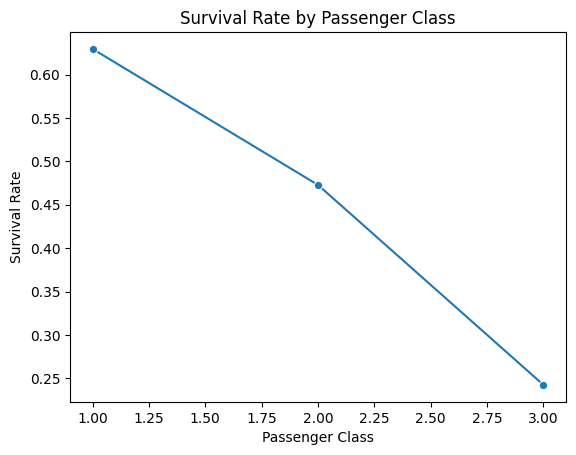

In [ ]:
survival_by_rate = df.groupby('pclass')['survived'].mean().reset_index()

sns.lineplot(data=survival_by_rate, x='pclass', y='survived', marker='o')
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

Q8. Scatter Plot – Age vs Fare

Intuition:

Higher fare passengers more likely survived.

Age does not strongly correlate with fare.

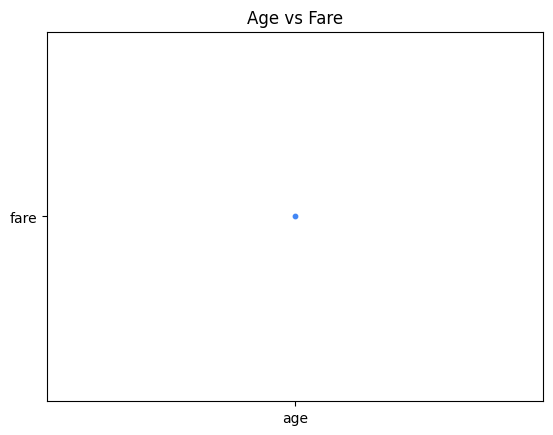

In [ ]:
plt.scatter(x='age',y='fare',color="#4287f5",s=10)
plt.title("Age vs Fare")
plt.show()

Q9. Boxplot – Age Distribution by Survival

Intuition:

Children had higher survival rate.

Outliers present in older ages.

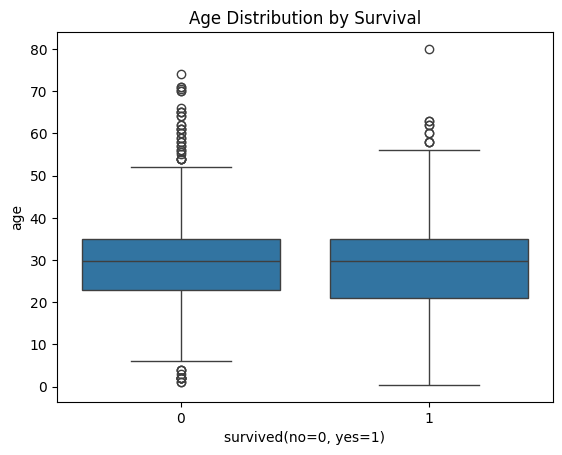

In [ ]:
sns.boxplot(data=df,x="survived",y="age")
plt.title("Age Distribution by Survival")
plt.xlabel("survived(no=0, yes=1)")
plt.ylabel("age")
plt.show()

Q10. Histplot – Age Distribution

Intuition:

Most passengers between 20–40.

Slight right skew.

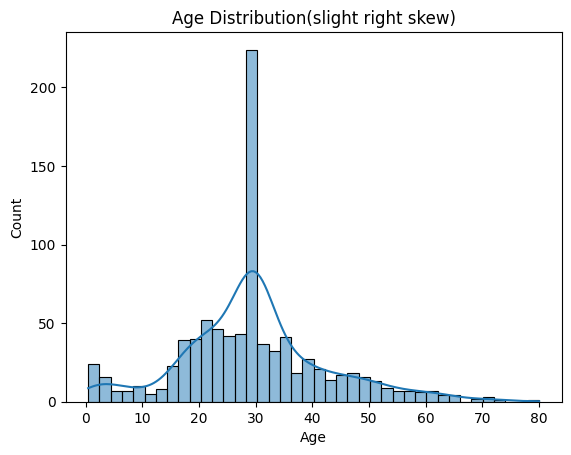

In [ ]:
sns.histplot(data=df,x='age', bins=40, kde=True)

plt.title("Age Distribution(slight right skew)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Q11. Displot – Fare Distribution

Intuition:

Highly right-skewed.

Few passengers paid very high fares.

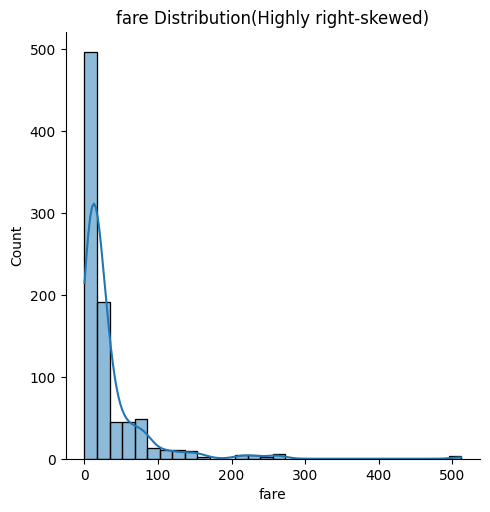

In [ ]:
sns.displot(data=df,x='fare', bins=30, kde=True)

plt.title("fare Distribution(Highly right-skewed)")
plt.xlabel("fare")
plt.ylabel("Count")
plt.show()

Q12. Catplot – Survival by Gender

Intuition:

Females had much higher survival rate.

Strong gender impact.

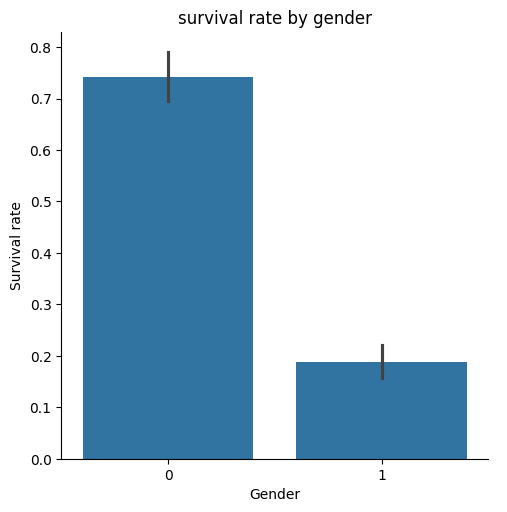

In [ ]:
sns.catplot(data=df,x='sex',y='survived',kind='bar')

plt.title("survival rate by gender")
plt.xlabel("Gender")
plt.ylabel("Survival rate")
plt.show()

Q13. Find average fare using NumPy.



In [ ]:
average_fare = np.mean(df['fare'])
average_fare

np.float64(32.204207968574636)

Q14. Find standard deviation of age.

In [ ]:
std_age = np.std(df['age'])
std_age

12.994716872789033

Q15. Create Age Category using NumPy.

If age < 18 → Child

Else → Adult

In [ ]:
np.where(df['age']<18,'child','adult')

array(['adult', 'adult', 'adult', 'adult', 'adult', 'adult', 'adult',
       'child', 'adult', 'child', 'child', 'adult', 'adult', 'adult',
       'child', 'adult', 'child', 'adult', 'adult', 'adult', 'adult',
       'adult', 'child', 'adult', 'child', 'adult', 'adult', 'adult',
       'adult', 'adult', 'adult', 'adult', 'adult', 'adult', 'adult',
       'adult', 'adult', 'adult', 'adult', 'child', 'adult', 'adult',
       'adult', 'child', 'adult', 'adult', 'adult', 'adult', 'adult',
       'adult', 'child', 'adult', 'adult', 'adult', 'adult', 'adult',
       'adult', 'adult', 'child', 'child', 'adult', 'adult', 'adult',
       'child', 'adult', 'adult', 'adult', 'adult', 'child', 'adult',
       'adult', 'child', 'adult', 'adult', 'adult', 'adult', 'adult',
       'adult', 'child', 'adult', 'adult', 'adult', 'adult', 'adult',
       'child', 'adult', 'child', 'adult', 'adult', 'adult', 'adult',
       'adult', 'adult', 'adult', 'adult', 'adult', 'adult', 'adult',
       'adult', 'adu

Interpretation Based Questions (Critical Thinking)


Why did 1st class passengers survive more?

Why is fare distribution right-skewed?

Is age strongly affecting survival?

Why convert categorical data into numerical?

What happens if we don’t clean missing values?